## Model-Based Segmentation

#### Installs and Imports

In [6]:
import os
import cv2
import numpy as np


import matplotlib.pyplot as  plt
plt.style.use('seaborn-white')
import seaborn as sns
sns.set_style("white")

from matplotlib.gridspec import GridSpec

import keras.backend as K

from datetime import datetime 

# import segmentation_models as sm
# from tensorflow.keras.metrics import MeanIoU
from glob import glob
from random import randint
from focal_loss import SparseCategoricalFocalLoss
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda, Activation

In [3]:
root_dir = '../data/external'
img_path_list = glob(os.path.join(root_dir, 'images/**/*.jpg'))
mask_path_list = [path.replace('images', 'annotations').replace('.jpg', '_mask.png') for path in img_path_list]

### Multi-Class Segmenatation Using UNet

#### Patching and Unpatching Image

In [7]:
def Patch(img, patch_size):
    patchs = []
    for i in range(0, img.shape[0], patch_size):
        for j in range(0, img.shape[1], patch_size):
            patch = img[i:i+patch_size, j:j+patch_size]
            patchs.append(patch)
    return np.array(patchs)

def Unpatch(patchs, img_shape):
    row_range = img_shape[0]//patchs.shape[1]
    clmn_range = img_shape[1]//patchs.shape[2]
    patchs_ = np.reshape(patchs, (row_range, clmn_range, *patchs.shape[1:]))

    clmn_stacks = []
    for r_patchs in patchs_:
        clmn_stacks.append(np.concatenate(r_patchs, axis=1))
    return np.concatenate(clmn_stacks, axis=0)

def EncodeLabel(mask, n_classes, to_catagorical=False):
    Encoder = LabelEncoder()
    mask_flat = mask.reshape((-1))
    encoded_mask = Encoder.fit_transform(mask_flat) # [0 176 255] to [0 1 2]
    encoded_mask = encoded_mask.reshape(mask.shape)
    if to_catagorical:
        encoded_mask = to_categorical(encoded_mask, num_classes=n_classes)
    return encoded_mask

def Normalize(img):
    Scaler = MinMaxScaler()
    flat_img = img.reshape((-1))
    normalized_img = Scaler.fit_transform(flat_img) # 0-255 to 0-1
    normalized_img = normalized_img.reshape(img.shape)
    return normalized_img

#### Visualize Patching and Unpatching

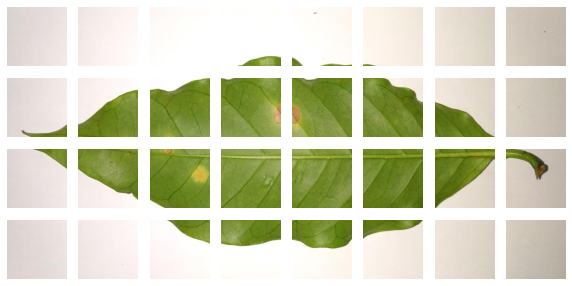

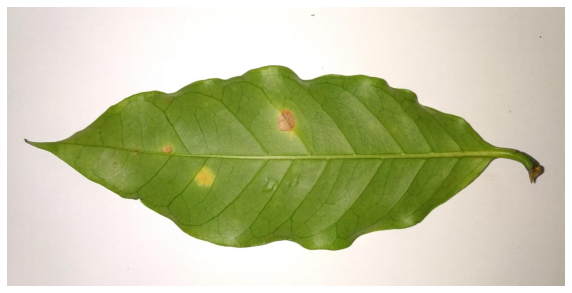

In [5]:
idx = randint(0, len(img_path_list))
patch_size=256
# patch_size=1024

img = cv2.cvtColor(cv2.imread(img_path_list[idx]), cv2.COLOR_BGR2RGB)

patched_img = Patch(img, patch_size)
unpatched_img = Unpatch(patched_img, img.shape)

ncols, nrows = img.shape[1]//patch_size, img.shape[0]//patch_size

gs = GridSpec(nrows, ncols)
fig1 = plt.figure(figsize=(10, 5))
for r in range(nrows):
    for c in range(ncols):
        ax = fig1.add_subplot(gs[r, c])
        ax.imshow(patched_img[(r*ncols+c)])
        ax.axis('off')

plt.figure(figsize=(10, 6))
plt.imshow(unpatched_img)
plt.axis('off')

plt.show()

#### Image Preprocessing

In [16]:
patched_img, patched_mask = [], []
_patch_size = 256

for idx in range(len(img_path_list)):
    _img = cv2.imread(img_path_list[idx])
    _mask = cv2.imread(mask_path_list[idx])
    patched_img.append(Patch(_img, _patch_size))
    patched_mask.append(Patch(_mask, _patch_size))   


patched_img = np.array(patched_img)     # (500, 32, 256, 256, 3)
patched_mask = np.array(patched_mask)

patched_img = np.reshape(patched_img, (-1, *patched_img.shape[2:])) #(16000, 256, 256, 3)
patched_mask = np.reshape(patched_mask, (-1, *patched_mask.shape[2:]))

train_img, test_img, train_mask, test_mask = train_test_split(patched_img, patched_mask, test_size=0.1, shuffle=False)
train_img, val_img, train_mask, val_mask = train_test_split(train_img, train_mask, test_size=0.2, shuffle=False)

#### Image Augmentation

In [ ]:
def Generator(img_arr, mask_arr, gen_kwargs, img_preprocessor, mask_preprocessor, batch_size=32, seed=10):
    Datagen = ImageDataGenerator(**gen_kwargs, preprocessing_function=img_preprocessor)        # preprocess the image to suit the model requirements
    image_generator = Datagen.flow(img_arr, batch_size=batch_size, shuffle=False, seed=seed) # apply the same seed to ensure the same transormation both for the img and the mask

    Datagen = ImageDataGenerator(**gen_kwargs, preprocessing_function=mask_preprocessor)
    mask_generator = Datagen.flow(mask_arr, batch_size=batch_size, shuffle=False, seed=seed)
    for (img, mask) in zip(image_generator, mask_generator):
        yield (img, mask)
    # return zip(image_generator, mask_generator)

In [ ]:
generator_kwargs = {'rotation_range': 3,
                    'width_shift_range': 0.2,
                    'height_shift_range': 0.2, 
                    'horizontal_flip': True,
                    'vertical_flip': True, 
                    'validation_split': 0.2}

train_generator = Generator(img_arr=train_img, 
                            mask_arr=train_mask, 
                            gen_kwargs=generator_kwargs,
                            img_preprocessor=Normalize, 
                            mask_preprocessor=EncodeLabel,
                            seed=10)

val_generator = Generator(img_arr=val_img, 
                          mask_arr=val_mask, 
                          gen_kwargs=generator_kwargs, 
                          img_preprocessor=Normalize, 
                          mask_preprocessor=EncodeLabel,
                          seed=10)

test_generator = Generator(img_arr=test_img, 
                          mask_arr=test_mask, 
                          gen_kwargs={}, 
                          img_preprocessor=Normalize, 
                          mask_preprocessor=EncodeLabel,
                          seed=None)

In [ ]:
def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) + 1.0)


def jacard_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (intersection + 1.0) / (K.sum(y_true_f) + K.sum(y_pred_f) - intersection + 1.0)


def jacard_coef_loss(y_true, y_pred):
    return -jacard_coef(y_true, y_pred)


def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)


#### Vanilla Unet Model

In [ ]:
def ConvBlock(input, n_filters, set_batchnorm=True, set_dropout=False):
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(input)
    if set_batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(n_filters, 3, padding='same', kernel_initializer='he_normal')(x)
    if set_batchnorm:
        x = BatchNormalization()(x)    
    x = Activation('relu')(x)
    if set_dropout:
        x = Dropout(0.2)(x)
    return x

def EncoderBlock(input, n_filters, set_batchnorm=True, set_dropout=False):
    x = ConvBlock(input, n_filters, set_batchnorm, set_dropout)
    p = MaxPooling2D((2, 2))(x)
    return x, p

def DecoderBlock(input, skip_features, n_filters):
    x = Conv2DTranspose(n_filters, (2, 2), strides=2, padding='same')(input)
    x = concatenate([x, skip_features])
    x = ConvBlock(x, n_filters)
    return x


def Unet(input_shape, n_classes, n_filters, set_batchnorm=True, set_dropout=False):
    inputs = Input(input_shape)

    conv1, pool1 = EncoderBlock(inputs, n_filters, set_batchnorm=True, set_dropout=False)
    conv2, pool2 = EncoderBlock(pool1, n_filters*2, set_batchnorm=True, set_dropout=False)
    conv3, pool3 = EncoderBlock(pool2, n_filters*4, set_batchnorm=True, set_dropout=False)
    conv4, pool4 = EncoderBlock(pool3, n_filters*8, set_batchnorm=True, set_dropout=False)

    midconv = ConvBlock(pool4, n_filters*16) # Bottleneck layer

    deconv1 = DecoderBlock(midconv, conv4, n_filters*8)
    deconv2 = DecoderBlock(deconv1, conv3, n_filters*4)
    deconv3 = DecoderBlock(deconv2, conv2, n_filters*2)
    deconv4 = DecoderBlock(deconv3, conv1, n_filters)

    outputs = Conv2D(n_classes, 1, padding='same', activation='Softmax')(deconv4)

    model = Model(inputs, outputs, name='Vanilla UNet')
    return model

In [ ]:
model = Unet(input_shape=(256, 256, 3), n_filters=64)
print(model.summary())

# model.summary()
lr_schedule = ExponentialDecay(initial_learning_rate=0.001,
                               decay_steps=118,
                               decay_rate=0.97,
                               staircase=True)
 
model.compile(loss=SparseCategoricalFocalLoss(gamma=2),
              optimizer= Adam(learning_rate=lr_schedule),
              metrics=['accuracy', jacard_coef])

In [ ]:
num_epochs = 3
check_point = ModelCheckpoint(filepath='./Checkpoints',
                              monitor='',
                              verbose=1,
                              save_best_only=True,
                              save_weights_only=True, 
                              mode='auto',
                              save_freq='epoch')
                              
early_stop = EarlyStopping(monitor='',
                           min_delta=0.001,
                           patience=3,
                           verbose=1)
                           
start = datetime.now() 

hist = model.fit(train_generator,
                 steps_per_epoch =train_generator.n//train_generator.batch_size,
                 epochs = num_epochs,
                 verbose=2,
                 validation_data = val_generator,
                 validation_steps=val_generator.n//val_generator.batch_size,
                 callbacks = [check_point, early_stop])   


stop = datetime.now()
execution_time= stop - start
print(f'Execution time: {execution_time}')

model.save('./SavedModel')                              

In [ ]:
loss, acc = model.evaluate(test_generator, verbose=0)
print("    Test Loss: {:.5f}".format(loss))
print("Test Accuracy: {:.2f}%".format(acc * 100))

### Segmentation Using DeepLabV3+

### Segmentation Using Segmentation Models